In [1]:
import pickle

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from modeling.SlamSimulator import SlamSimulator
from utility.Point2d import Point2d


seed_list = [445, 727, 10032]
num_landmarks_list = [0, 3, 20, 50, 150]
trajectory_name_list = ["square_1", "square_2", "spiral_1", "spiral_2"]
trajectories = {
    "square_1" : [Point2d(50, 50), Point2d(50, -50), Point2d(-50, -50), Point2d(-50, 50), Point2d(50, 50), Point2d(0, 0)],
    "square_2" : [Point2d(0, 50), Point2d(50, 0), Point2d(0, -50), Point2d(-50, 0), Point2d(0, 50), Point2d(0, 0)],
    "spiral_1" : [Point2d(0, 20), Point2d(20, 20), Point2d(20, -40), Point2d(-40, -40), 
                    Point2d(-40, 60), Point2d(60, 60), Point2d(60, -80), Point2d(-80, -80)],
    "spiral_2" : [Point2d(1, 1), Point2d(3, -1), Point2d(3, -4), Point2d(0, -5), Point2d(-3, -3), Point2d(-5, 0), Point2d(-3, 5),  
                Point2d(0, 8), Point2d(5, 8), Point2d(10, 4), Point2d(14, -4), Point2d(10, -10), Point2d(1, -14), Point2d(-12, -9),  
                Point2d(-16, 3), Point2d(-10, 14), Point2d(-1, 23), Point2d(13, 20), Point2d(24, 7), Point2d(27, -6), Point2d(17, -18),  
                Point2d(2, -28), Point2d(-15, -25), Point2d(-31, -6), Point2d(-26, 17), Point2d(-11, 34), Point2d(14, 35), Point2d(32, 21),  
                Point2d(41, 0), Point2d(29, -28), Point2d(11, -41), Point2d(-21, -44), Point2d(-41, -31)],
}
u_noise_list = [[1e-1, 1e-1], [0.5, 0.5], [1, 1], [2, 2]]
h_noise_list = [[2.0, 3.0], [20.0, 25.0], [40.0, 50.0]]

split_names = [
    "predict",
    "update",
    "compare_observations_to_state",
    "calculate_mahal_dists",
    "create_new_object_if_needed",
    "match_object",
    "use_matching_detection",
    "detections_loop_p1",
    "detections_loop_p2",
    "detections_loop_p3",
    "detections_loop_p4",
    "detections_loop_p5",
    "detections_loop_p6",
    "detections_loop_p7"
]

In [12]:
metrics1 = pd.read_csv("slam_simulator_metrics.csv")
metrics2 = pd.read_csv("slam_simulator_metrics_2.csv")
metrics1 = metrics1.set_index(["seed", "num_landmarks", "trajectory_name", "u_noise", "h_noise"])
metrics2 = metrics2.set_index(["seed", "num_landmarks", "trajectory_name", "u_noise", "h_noise"])
assert metrics1.shape[0] == metrics2.shape[0]
metrics = metrics1.join(metrics2)

In [34]:
seed = 445
num_landmarks = 150
trajectory_name = "square_1"
u_noise = [0.5, 0.5]
h_noise = [2.0, 3.0]
# metrics.loc[pd.IndexSlice[seed, num_landmarks, trajectory_name, str(u_noise), str(h_noise)]]
metrics.loc[pd.IndexSlice[seed, :, trajectory_name, str(u_noise), :]]

player_mse     lm_mse  correct_match_count  \
num_landmarks h_noise                                                    
0             [2.0, 3.0]      0.549920  -1.000000                    0   
              [20.0, 25.0]    0.549920  -1.000000                    0   
              [40.0, 50.0]    0.549920  -1.000000                    0   
3             [2.0, 3.0]      0.611051   1.378678                    3   
              [20.0, 25.0]    0.485146   4.775170                    2   
              [40.0, 50.0]    0.493396  17.442053                    1   
20            [2.0, 3.0]      0.761071   0.154350                  449   
              [20.0, 25.0]    0.999239   2.683213                  445   
              [40.0, 50.0]    3.005473  12.474489                  420   
50            [2.0, 3.0]      0.311517   0.137970                 1772   
              [20.0, 25.0]    0.152376   2.949477                 1745   
              [40.0, 50.0]    0.881843  15.281979                 1681   
150           [2.0, 3.0]      0.006784   0.013628                 5139   
              [20.0, 25.0]    0.208937   2.645800                 5090   
              [40.0, 50.0]    0.954002  11.970252                 4881   

                            wrong_match_count  bad_new_creation_count  \
num_landmarks h_noise                                                   
0             [2.0, 3.0]                    0                       0   
              [20.0, 25.0]                  0                       0   
              [40.0, 50.0]                  0                       0   
3             [2.0, 3.0]                    0                       0   
              [20.0, 25.0]                  0                       1   
              [40.0, 50.0]                  0                       2   
20            [2.0, 3.0]                    0                       0   
              [20.0, 25.0]                  0                       4   
              [40.0, 50.0]                  0                      29   
50            [2.0, 3.0]                    0                       5   
              [20.0, 25.0]                  0                      32   
              [40.0, 50.0]                  0                      96   
150           [2.0, 3.0]                    0                      36   
              [20.0, 25.0]                  0                      85   
              [40.0, 50.0]                 23                     271   

                            new_object_match_count  
num_landmarks h_noise                               
0             [2.0, 3.0]                         0  
              [20.0, 25.0]                       0  
              [40.0, 50.0]                       0  
3             [2.0, 3.0]                         0  
              [20.0, 25.0]                       0  
              [40.0, 50.0]                       0  
20            [2.0, 3.0]                         0  
              [20.0, 25.0]                       0  
              [40.0, 50.0]                       0  
50            [2.0, 3.0]                         0  
              [20.0, 25.0]                       0  
              [40.0, 50.0]                       0  
150           [2.0, 3.0]                         0  
              [20.0, 25.0]                       0  
              [40.0, 50.0]                       0

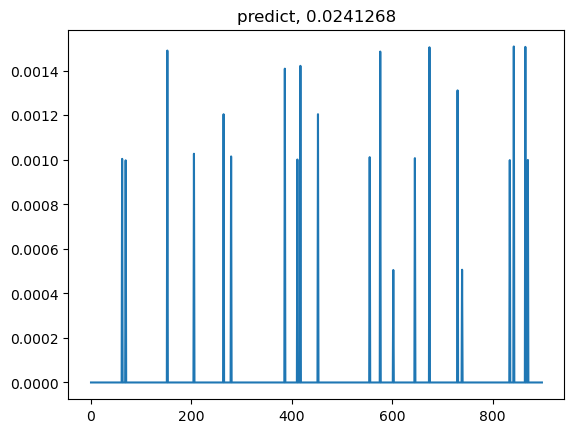

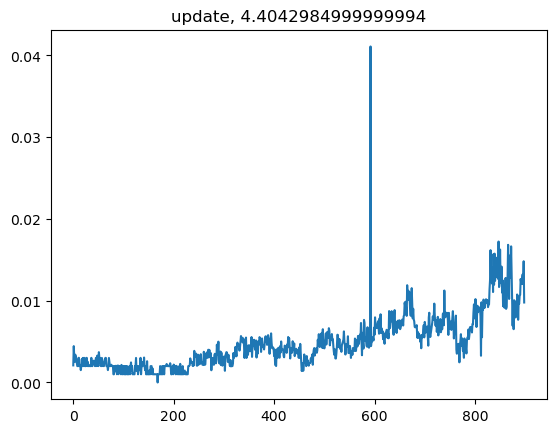

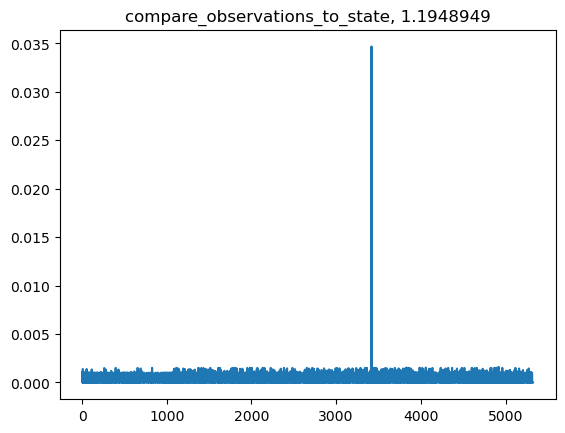

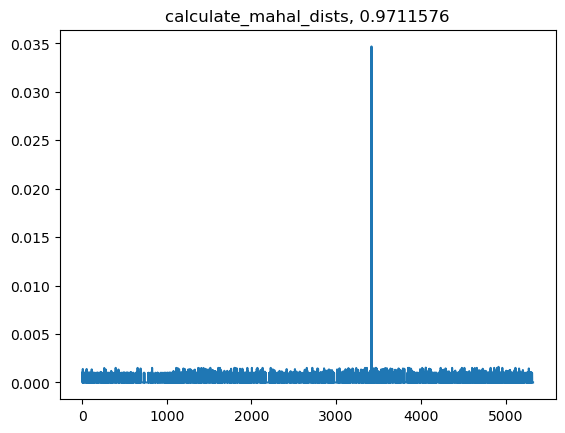

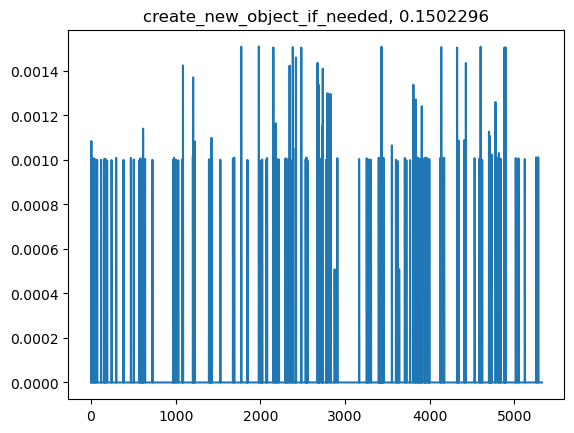

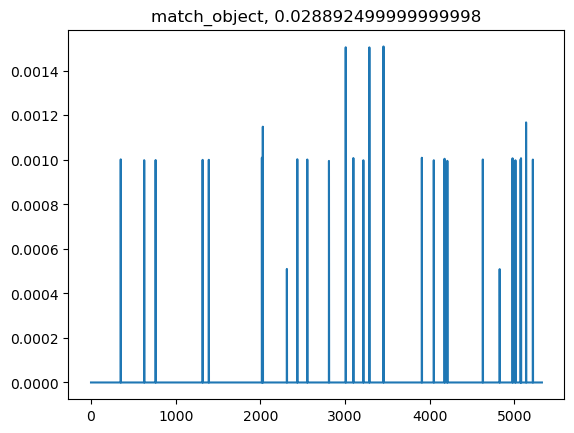

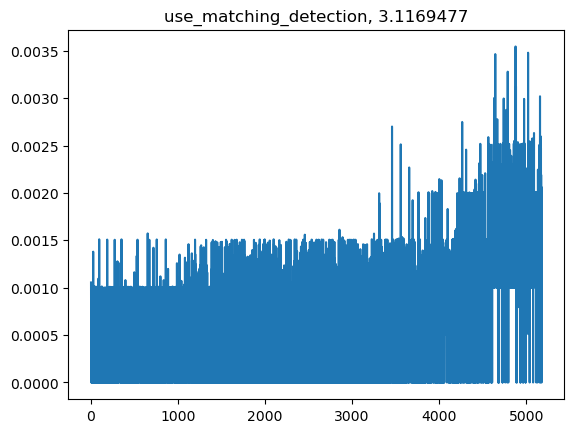

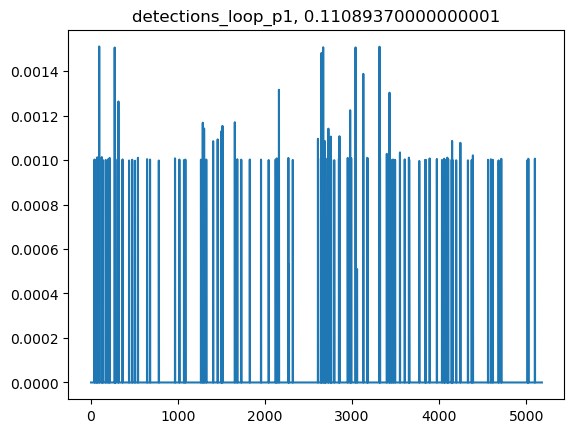

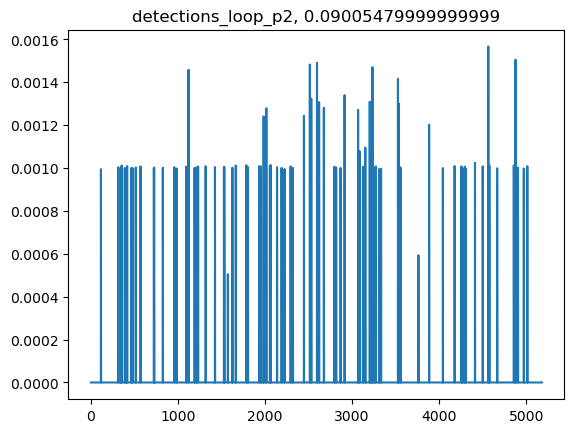

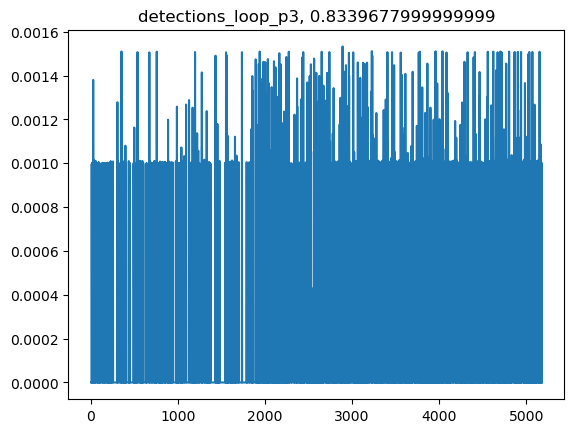

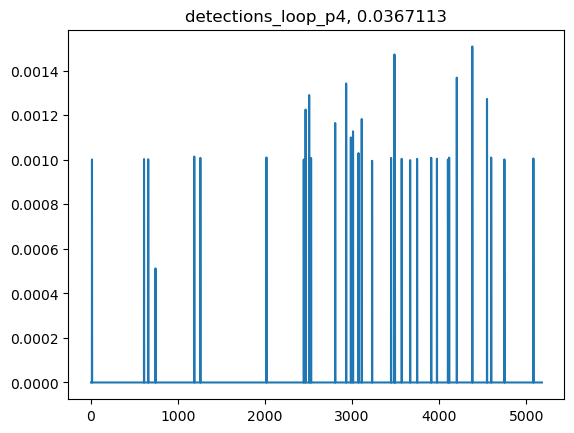

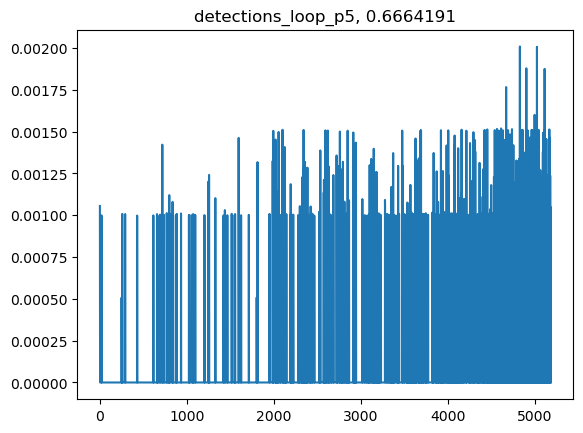

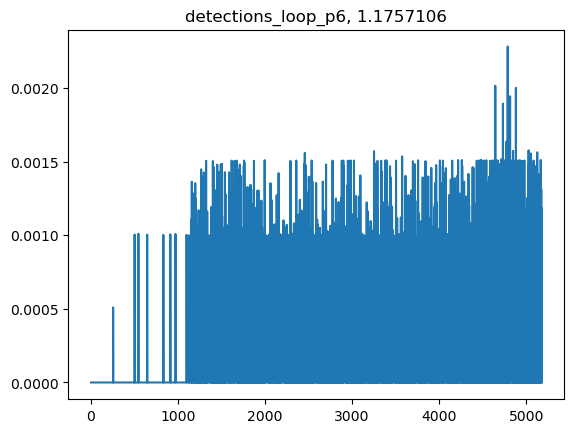

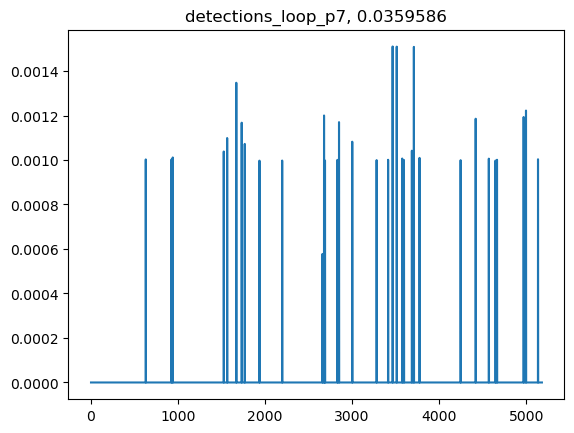

In [2]:
seed = 445
num_landmarks = 150
trajectory_name = "square_1"
u_noise = [2, 2]
h_noise = [2.0, 3.0]
for split_name in split_names:
    times = np.load(f"slam_simulator_results/slam_times__{split_name}__{seed}__{num_landmarks}__{trajectory_name}__{str(u_noise[0])}__{str(u_noise[1])}__{str(h_noise[0])}__{str(h_noise[1])}.npy")
    times = times/1e9
    times_pd = pd.Series(times[:, 0])
    plt.figure()
    plt.title(f"{split_name}, {times.sum()}")
    times_pd.plot()
    # update_times = np.load(f"slam_simulator_results/slam_times__update__{seed}__{num_landmarks}__{trajectory_name}__{str(u_noise[0])}__{str(u_noise[1])}__{str(h_noise[0])}__{str(h_noise[1])}.npy")
    # predict_times = np.load(f"slam_simulator_results/slam_times__predict__{seed}__{num_landmarks}__{trajectory_name}__{str(u_noise[0])}__{str(u_noise[1])}__{str(h_noise[0])}__{str(h_noise[1])}.npy")
    # total_times = update_times + predict_times
    # total_times = total_times/1e9
    # print(total_times.mean())
    # times_pd = pd.Series(total_times[:, 0])
    # print(num_landmarks, trajectory_name)
    # print(times_pd.describe())
    # plt.figure()
    # plt.plot(total_times)
    # plt.title("total")

In [10]:
state_sizes = []
with open(f"slam_simulator_results/state_estimate__{seed}__{num_landmarks}__{trajectory_name}__{str(u_noise[0])}__{str(u_noise[1])}__{str(h_noise[0])}__{str(h_noise[1])}.pkl", "rb") as file:
    state_list = pickle.load(file)
    for state in state_list:
        state_sizes.append(state.shape)
print(state_sizes)


[(2, 1), (18, 1), (18, 1), (18, 1), (18, 1), (18, 1), (18, 1), (18, 1), (18, 1), (18, 1), (18, 1), (18, 1), (18, 1), (18, 1), (18, 1), (18, 1), (18, 1), (18, 1), (18, 1), (20, 1), (20, 1), (20, 1), (22, 1), (22, 1), (22, 1), (24, 1), (26, 1), (28, 1), (28, 1), (28, 1), (28, 1), (28, 1), (28, 1), (28, 1), (28, 1), (28, 1), (28, 1), (28, 1), (30, 1), (30, 1), (30, 1), (32, 1), (32, 1), (32, 1), (32, 1), (34, 1), (34, 1), (34, 1), (36, 1), (36, 1), (36, 1), (38, 1), (38, 1), (38, 1), (38, 1), (38, 1), (38, 1), (38, 1), (38, 1), (38, 1), (38, 1), (38, 1), (38, 1), (38, 1), (38, 1), (38, 1), (38, 1), (38, 1), (38, 1), (38, 1), (38, 1), (38, 1), (38, 1), (38, 1), (38, 1), (38, 1), (38, 1), (38, 1), (38, 1), (38, 1), (38, 1), (38, 1), (40, 1), (42, 1), (42, 1), (42, 1), (42, 1), (42, 1), (42, 1), (42, 1), (42, 1), (42, 1), (44, 1), (44, 1), (44, 1), (44, 1), (44, 1), (44, 1), (44, 1), (44, 1), (44, 1), (44, 1), (44, 1), (44, 1), (44, 1), (44, 1), (44, 1), (44, 1), (44, 1), (44, 1), (46, 1), (

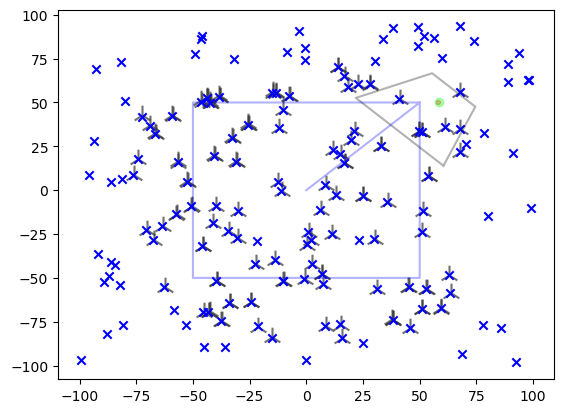

In [12]:
seed = 445
num_landmarks = 150
trajectory_name = "square_1"
u_noise = [2, 2]
h_noise = [2.0, 3.0]
expected_trajectory = np.array([[p.x1, p.x2] for p in trajectories[trajectory_name]])
sim = SlamSimulator(0, 0, [], [0, 0], [0, 0])
trapezoid = sim.vision_trapezoid
trapezoid_np = np.array([[p.x1, p.x2] for p in trapezoid])
plt.clf()
i = 800
player_positions_gt = np.load(f"slam_simulator_results/player_positions_gt__{seed}__{num_landmarks}__{trajectory_name}__{str(u_noise[0])}__{str(u_noise[1])}__{str(h_noise[0])}__{str(h_noise[1])}.npy")
with open(f"slam_simulator_results/state_estimate__{seed}__{num_landmarks}__{trajectory_name}__{str(u_noise[0])}__{str(u_noise[1])}__{str(h_noise[0])}__{str(h_noise[1])}.pkl", "rb") as file:
    state_list = pickle.load(file)
player_temp_list = []
lm_list = []
for state in state_list:
    player_temp_list.append([state[0, 0], state[1, 0]])
    lm_temp_temp_list = []
    for j in range((state.shape[0]-2)//2):
        lm_temp_temp_list.append([state[2+2*j, 0], state[2+2*j+1, 0]])
    lm_list.append(np.array(lm_temp_temp_list))
player_positions_estimate = np.array(player_temp_list)
plt.scatter(player_positions_gt[i, 0], player_positions_gt[i, 1], marker='.', color=(1.0, 0, 0, 0.3))
plt.scatter(player_positions_estimate[i, 0], player_positions_estimate[i, 1], marker='o', color=(0, 1.0, 0, 0.3))
if lm_list[i].shape[0] != 0:
    plt.scatter(lm_list[i][:, 0], lm_list[i][:, 1], marker='2', s=200, color=(.2, .2, .2, .7))
plt.plot(expected_trajectory[:, 0], expected_trajectory[:, 1], color=(0, 0, 1.0, 0.3))
moved_trapezoid_np = trapezoid_np+player_positions_gt[i]
plt.plot(moved_trapezoid_np[:, 0], moved_trapezoid_np[:, 1], color=[0, 0, 0, 0.3])
if num_landmarks > 0:
    landmarks = np.load(f"slam_simulator_results/landmark_positions__{seed}__{num_landmarks}.npy")
    plt.scatter(landmarks[:, 0], landmarks[:, 1], marker='x', color=(0, 0, 1.0))

Files not found
Files not found
Files not found


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

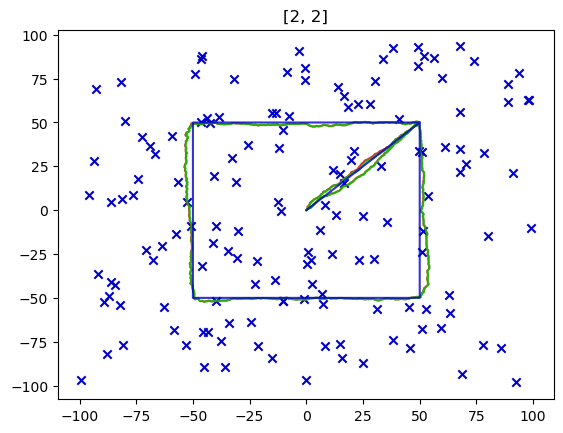

In [3]:
seed = 445
num_landmarks = 150
trajectory_name = "square_1"
u_noise = [2, 2]
h_noise = [2.0, 3.0]
expected_trajectory = np.array([[p.x1, p.x2] for p in trajectories[trajectory_name]])
plt.clf()
for i, u_noise in enumerate(u_noise_list):
    plt.figure()
    mult = (i+1)/(len(u_noise_list)+1)
    try:
        player_positions_gt = np.load(f"slam_simulator_results/player_positions_gt__{seed}__{num_landmarks}__{trajectory_name}__{str(u_noise[0])}__{str(u_noise[1])}__{str(h_noise[0])}__{str(h_noise[1])}.npy")
        with open(f"slam_simulator_results/state_estimate__{seed}__{num_landmarks}__{trajectory_name}__{str(u_noise[0])}__{str(u_noise[1])}__{str(h_noise[0])}__{str(h_noise[1])}.pkl", "rb") as file:
            state_list = pickle.load(file)
        if num_landmarks > 0:
            landmarks = np.load(f"slam_simulator_results/landmark_positions__{seed}__{num_landmarks}.npy")
            plt.scatter(landmarks[:, 0], landmarks[:, 1], marker='x', color=(0, 0, mult))
    except:
        print("Files not found")
        continue
    temp_list = []
    for state in state_list:
        temp_list.append([state[0, 0], state[1, 0]])
    player_positions_estimate = np.array(temp_list)
    plt.plot(player_positions_gt[:, 0], player_positions_gt[:, 1], color=(mult,0,0,mult))
    plt.plot(player_positions_estimate[:, 0], player_positions_estimate[:, 1], color=(0, mult, 0, mult))
    plt.plot(expected_trajectory[:, 0], expected_trajectory[:, 1], color=(0, 0, mult, mult))
    plt.title(u_noise)


Text(0.5, 1.0, 'lm 50 covariance x')

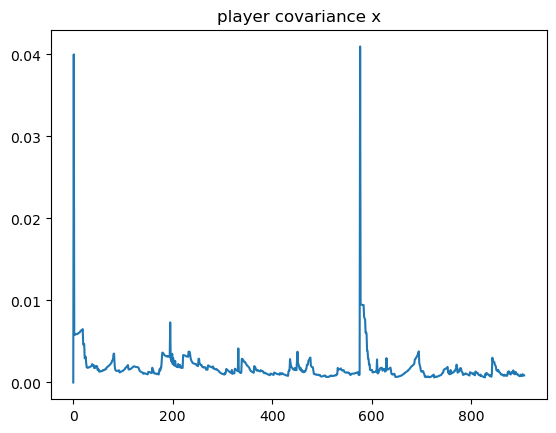

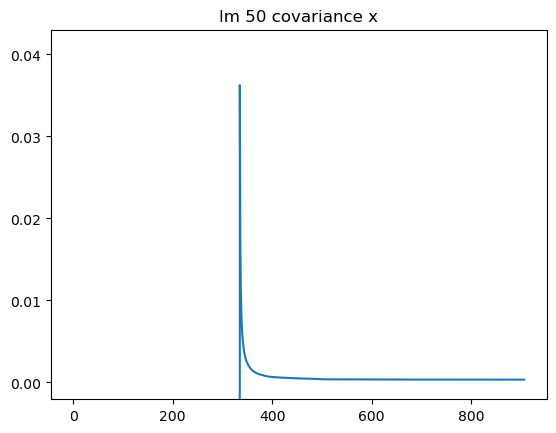

In [19]:
seed = 445
num_landmarks = 150
trajectory_name = "square_1"
u_noise = [2, 2]
h_noise = [2.0, 3.0]
with open(f"slam_simulator_results/covariance_estimate__{seed}__{num_landmarks}__{trajectory_name}__{str(u_noise[0])}__{str(u_noise[1])}__{str(h_noise[0])}__{str(h_noise[1])}.pkl", "rb") as file:
    covariance_list = pickle.load(file)
lm_id = 50
conv_lm_id = 2+2*lm_id
player_temp_list = []
lm_temp_list = []
for cov in covariance_list:
    player_temp_list.append([cov[0, 0], cov[1, 1]])
    if conv_lm_id < cov.shape[0]:
        lm_temp_list.append([cov[conv_lm_id, conv_lm_id], cov[conv_lm_id+1, conv_lm_id+1]])
    else:
        lm_temp_list.append([-1, -1])
player_covariance_estimate = np.array(player_temp_list)
lm_covariance_estimate = np.array(lm_temp_list)
plt.plot(player_covariance_estimate[:, 0])
player_cov_max_x = player_covariance_estimate[:, 0].max()
player_cov_min_x = player_covariance_estimate[1:, 0].min()
player_cov_range_x = player_cov_max_x - player_cov_min_x
plt.title(f"player covariance x")
xmin, xmax, ymin, ymax = plt.axis()
plt.figure()
plt.plot(lm_covariance_estimate[:, 0])
plt.ylim(ymin, ymax)
plt.title(f"lm {lm_id} covariance x")

Text(0.5, 1.0, 'player position estimate error')

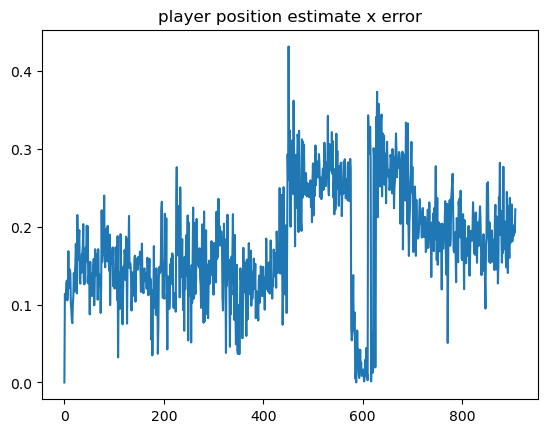

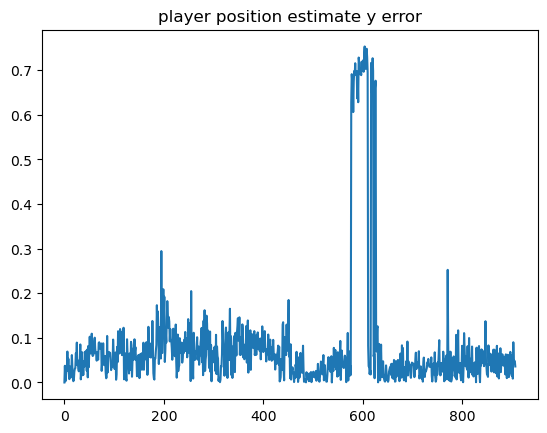

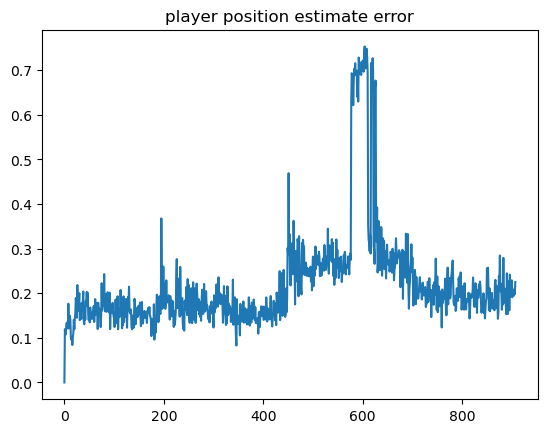

In [21]:
seed = 445
num_landmarks = 150
trajectory_name = "square_1"
u_noise = [2, 2]
h_noise = [2.0, 3.0]
expected_trajectory = np.array([[p.x1, p.x2] for p in trajectories[trajectory_name]])
sim = SlamSimulator(0, 0, [], [0, 0], [0, 0])
trapezoid = sim.vision_trapezoid
trapezoid_np = np.array([[p.x1, p.x2] for p in trapezoid])
plt.clf()
player_positions_gt = np.load(f"slam_simulator_results/player_positions_gt__{seed}__{num_landmarks}__{trajectory_name}__{str(u_noise[0])}__{str(u_noise[1])}__{str(h_noise[0])}__{str(h_noise[1])}.npy")
with open(f"slam_simulator_results/state_estimate__{seed}__{num_landmarks}__{trajectory_name}__{str(u_noise[0])}__{str(u_noise[1])}__{str(h_noise[0])}__{str(h_noise[1])}.pkl", "rb") as file:
    state_list = pickle.load(file)
player_temp_list = []
lm_list = []
for state in state_list:
    player_temp_list.append([state[0, 0], state[1, 0]])
    lm_temp_temp_list = []
    for j in range((state.shape[0]-2)//2):
        lm_temp_temp_list.append([state[2+2*j, 0], state[2+2*j+1, 0]])
    lm_list.append(np.array(lm_temp_temp_list))
player_positions_estimate = np.array(player_temp_list)
player_positions_error = np.abs(player_positions_estimate - player_positions_gt)
plt.plot(player_positions_error[:, 0])
plt.title("player position estimate x error")
plt.figure()
plt.plot(player_positions_error[:, 1])
plt.title("player position estimate y error")
plt.figure()
plt.plot(np.sqrt(player_positions_error[:, 0]**2+player_positions_error[:, 1]**2))
plt.title("player position estimate error")

Text(0.5, 1.0, 'mean: 0.00, std: 2.48')

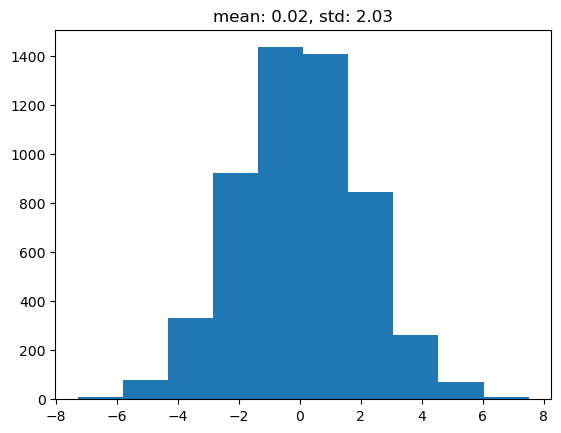

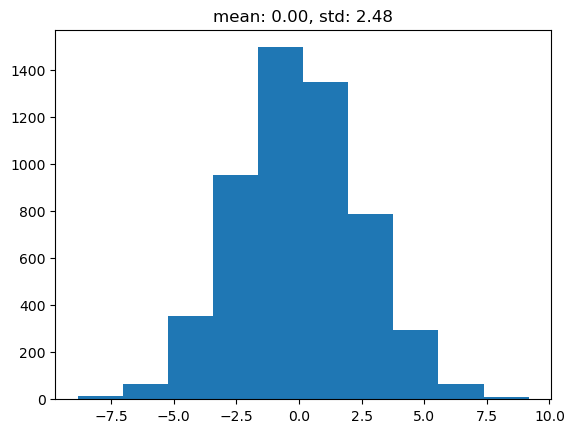

In [31]:
seed = 445
num_landmarks = 150
trajectory_name = "square_1"
u_noise = [1, 1]
h_noise = [2.0, 2.5]
measurement_errors = np.load(f"slam_simulator_results/measurement_errors__{seed}__{num_landmarks}__{trajectory_name}__{str(u_noise[0])}__{str(u_noise[1])}__{str(h_noise[0])}__{str(h_noise[1])}.npy")
plt.hist(measurement_errors[:, 0])
plt.title(f"mean: {measurement_errors[:, 0].mean():.2f}, std: {measurement_errors[:, 0].std():.2f}")
plt.figure()
plt.hist(measurement_errors[:, 1])
plt.title(f"mean: {measurement_errors[:, 1].mean():.2f}, std: {measurement_errors[:, 1].std():.2f}")

Text(0.5, 1.0, 'mean: -0.00, std: 0.08')

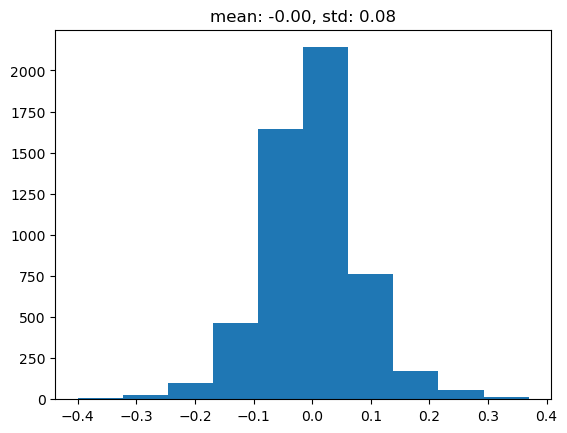

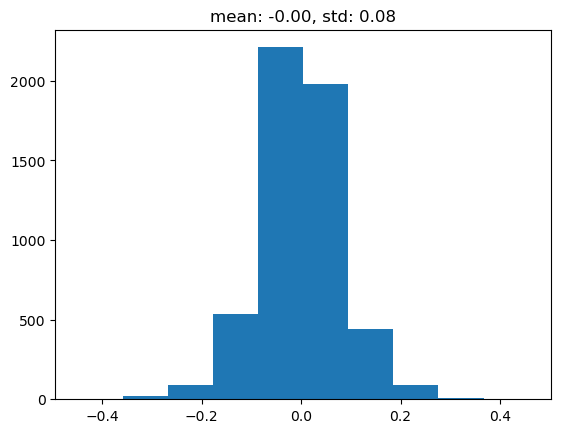

In [32]:
seed = 445
num_landmarks = 150
trajectory_name = "square_1"
u_noise = [1, 1]
h_noise = [2.0, 2.5]
measurement_position_errors = np.load(f"slam_simulator_results/measurement_position_errors__{seed}__{num_landmarks}__{trajectory_name}__{str(u_noise[0])}__{str(u_noise[1])}__{str(h_noise[0])}__{str(h_noise[1])}.npy")
plt.hist(measurement_position_errors[:, 0])
plt.title(f"mean: {measurement_position_errors[:, 0].mean():.2f}, std: {measurement_position_errors[:, 0].std():.2f}")
plt.figure()
plt.hist(measurement_position_errors[:, 1])
plt.title(f"mean: {measurement_position_errors[:, 1].mean():.2f}, std: {measurement_position_errors[:, 1].std():.2f}")

Text(0.5, 1.0, 'mean: -0.01, std: 0.98')

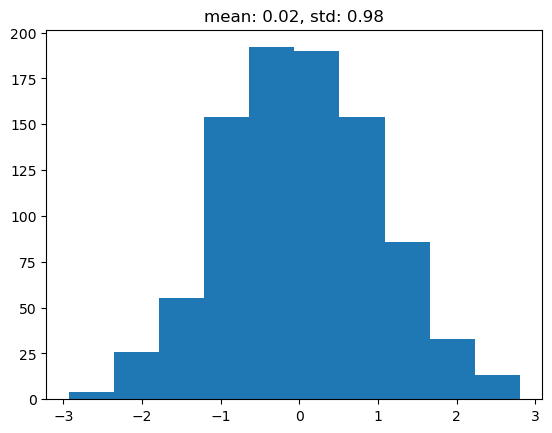

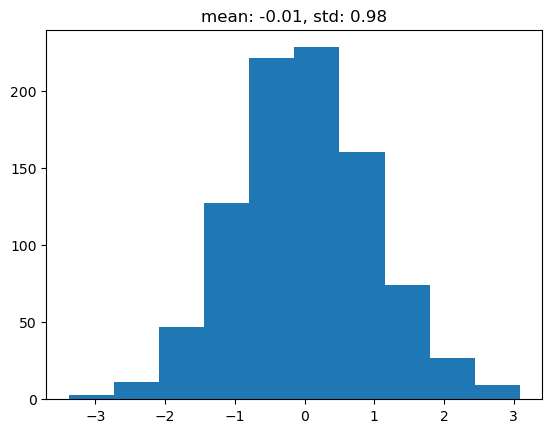

In [33]:
seed = 445
num_landmarks = 150
trajectory_name = "square_1"
u_noise = [1, 1]
h_noise = [2.0, 2.5]
speed_errors = np.load(f"slam_simulator_results/speed_errors__{seed}__{num_landmarks}__{trajectory_name}__{str(u_noise[0])}__{str(u_noise[1])}__{str(h_noise[0])}__{str(h_noise[1])}.npy")
plt.hist(speed_errors[:, 0])
plt.title(f"mean: {speed_errors[:, 0].mean():.2f}, std: {speed_errors[:, 0].std():.2f}")
plt.figure()
plt.hist(speed_errors[:, 1])
plt.title(f"mean: {speed_errors[:, 1].mean():.2f}, std: {speed_errors[:, 1].std():.2f}")

<Figure size 640x480 with 0 Axes>

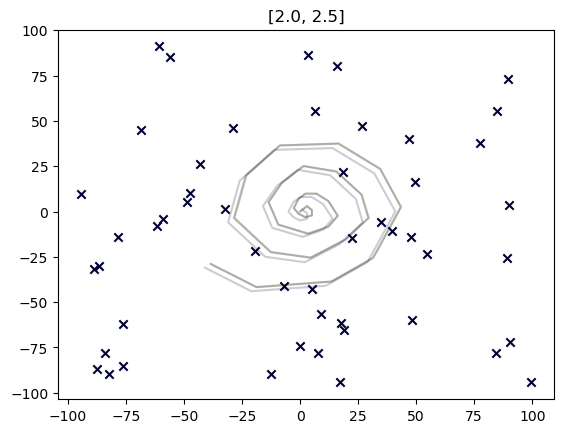

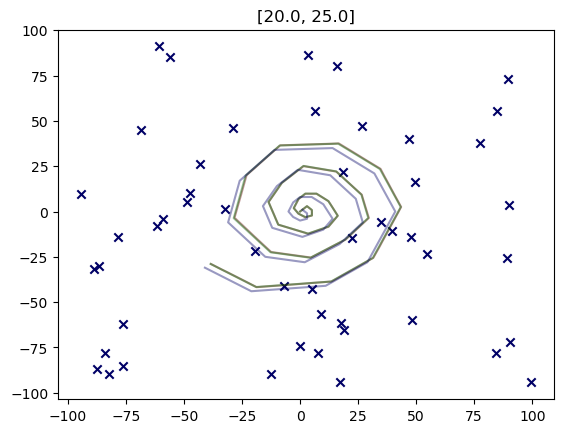

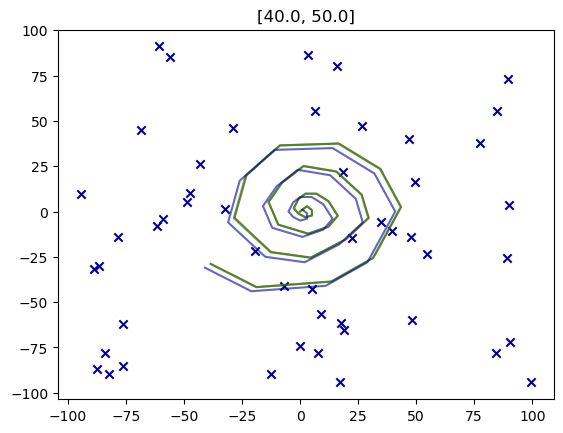

In [23]:
seed = 727
num_landmarks = 50
trajectory_name = "spiral_2"
u_noise = [0.1, 0.1]
# h_noise = [2.0, 2.5]
expected_trajectory = np.array([[p.x1, p.x2] for p in trajectories[trajectory_name]])
plt.clf()
for i, h_noise in enumerate(h_noise_list):
    plt.figure()
    mult = (i+1)/(len(u_noise_list)+1)
    player_positions_gt = np.load(f"slam_simulator_results/player_positions_gt__{seed}__{num_landmarks}__{trajectory_name}__{str(u_noise[0])}__{str(u_noise[1])}__{str(h_noise[0])}__{str(h_noise[1])}.npy")
    with open(f"slam_simulator_results/state_estimate__{seed}__{num_landmarks}__{trajectory_name}__{str(u_noise[0])}__{str(u_noise[1])}__{str(h_noise[0])}__{str(h_noise[1])}.pkl", "rb") as file:
        state_list = pickle.load(file)
    temp_list = []
    for state in state_list:
        temp_list.append([state[0, 0], state[1, 0]])
    player_positions_estimate = np.array(temp_list)
    plt.plot(player_positions_gt[:, 0], player_positions_gt[:, 1], color=(mult,0,0,mult))
    plt.plot(player_positions_estimate[:, 0], player_positions_estimate[:, 1], color=(0, mult, 0, mult))
    plt.plot(expected_trajectory[:, 0], expected_trajectory[:, 1], color=(0, 0, mult, mult))
    plt.title(h_noise)
    if num_landmarks > 0:
        landmarks = np.load(f"slam_simulator_results/landmark_positions__{seed}__{num_landmarks}.npy")
        plt.scatter(landmarks[:, 0], landmarks[:, 1], marker='x', color=(0, 0, mult))


In [25]:
arr_list = []
for h_noise in h_noise_list:
    arr1 = np.load(f"slam_simulator_results/player_positions_gt__{seed}__{num_landmarks}__{trajectory_name}__{str(u_noise[0])}__{str(u_noise[1])}__{str(h_noise[0])}__{str(h_noise[1])}.npy")
    arr_list.append(arr1)

for i in range(len(arr_list)-1):
    assert (arr_list[i] == arr_list[i+1]).all()

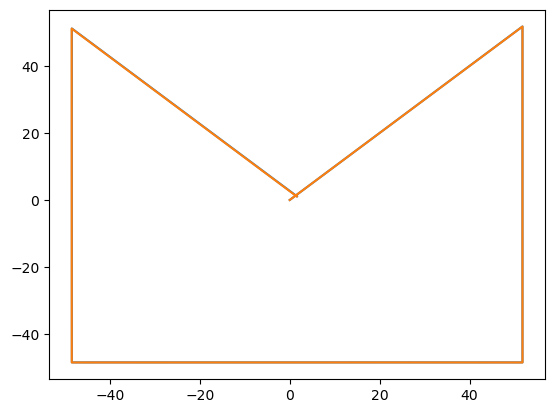

In [10]:
plt.plot(player_positions_gt[:, 0], player_positions_gt[:, 1])
plt.plot(player_positions_estimate[:, 0], player_positions_estimate[:, 1])

In [11]:
print(np.sum((player_positions_gt - player_positions_estimate)**2))

0.8645065421910958
